# 1. Import and Install Dependencies

## 1.2 Load Dependencies

In [1]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
from split_audio_by_duration import split_audio_by_duration 

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

print(tf.test.gpu_device_name())
print(tf.config.get_visible_devices())

Num GPUs Available:  0
False

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 2. Build Data Loading Function

## 2.1 Define Paths to Files

In [3]:
POSITIVE_FILE = os.path.join('audios', 'positive', '0.wav')
NEGATIVE_FILE = os.path.join('audios', 'negative', '0.wav')


In [4]:
file_contents = tf.io.read_file(POSITIVE_FILE)
file_contents

<tf.Tensor: shape=(), dtype=string, numpy=b'RIFF$}\x00\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x01\x00\x80>\x00\x00\x00}\x00\x00\x02\x00\x10\x00data\x00}\x00\x00\xcc\xf9\xa2\x06\xa2\x068\xf48\xf4p\xffp\xff@\xfa@\xfaB\xfeB\xfe\xbe\x00\xbe\x00\xa0\xf8\xa0\xf8\x0e\x02\x0e\x02x\xf7x\xf7p\xf9p\xf9\xc4\x02\xc4\x02\xd2\x00\xd2\x00v\xf6v\xf6\xde\xff\xde\xffB\xfcB\xfc:\xf9:\xf9\xfc\x06\xfc\x06\xf0\xfa\xf0\xfa\xf4\x00\xf4\x00\xa4\xfc\xa4\xfc\xa6\xff\xa6\xff\x12\xfc\x12\xfc\x82\xf9\x82\xf9\xf2\xff\xf2\xffL\xfbL\xfb@\xfe@\xfeH\xfdH\xfdn\xfdn\xfdL\xfdL\xfd\x8c\x01\x8c\x016\x006\x00\n\xfb\n\xfbj\xfcj\xfc\x08\xff\x08\xff\xda\x00\xda\x00.\xfd.\xfd\xda\xfc\xda\xfc\xdc\x02\xdc\x02N\x01N\x010\xf10\xf1\xf6\x00\xf6\x00\x9e\x03\x9e\x03z\xfez\xfe4\xff4\xff\xbc\xfa\xbc\xfa\x06\x04\x06\x04J\xf5J\xf5F\x00F\x00\xc4\x05\xc4\x05Z\xf2Z\xf2\xde\x05\xde\x05\xd2\xfe\xd2\xfe\xe2\xfc\xe2\xfc\xaa\x01\xaa\x01\xe4\xf9\xe4\xf9\x8a\xfc\x8a\xfc\x08\x00\x08\x00^\x04^\x04\x1a\xff\x1a\xffx\xfbx\xfb\xc2\xff\xc2\xffR\x01R\x01\x1a\xf9\

In [5]:
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
sample_rate

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

## 2.2 Build Dataloading Function

In [6]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

## 2.3 Plot Wave

In [7]:
wave = load_wav_16k_mono(POSITIVE_FILE)
nwave = load_wav_16k_mono(NEGATIVE_FILE)

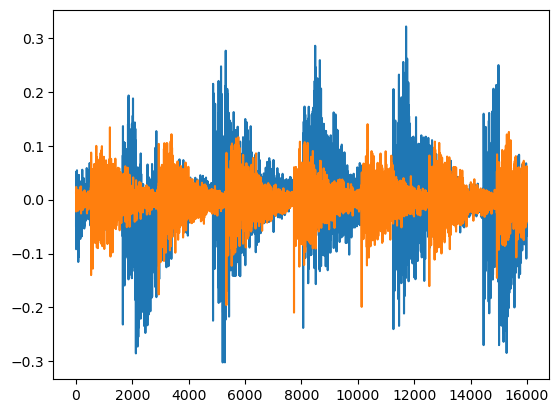

In [8]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

# 3. Create Tensorflow Dataset

## 3.1 Define Paths to Positive and Negative Data

In [9]:
POS = os.path.join('./', 'audios', 'positive')
NEG = os.path.join('./', 'audios', 'negative')

## 3.2 Create Tensorflow Datasets

In [10]:
pos = tf.data.Dataset.list_files(POS+'\*.wav')
neg = tf.data.Dataset.list_files(NEG+'\*.wav')

## 3.3 Add labels and Combine Positive and Negative Samples

In [11]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

# 4. Determine Average Length of a file

## 4.1 Calculate Wave Cycle Length

In [12]:
lengths = []
for file in os.listdir(os.path.join('./', 'audios', 'positive')):
    tensor_wave = load_wav_16k_mono(os.path.join('./', 'audios', 'positive', file))
    lengths.append(len(tensor_wave))

## 4.2 Calculate Mean, Min and Max

In [13]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [14]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [15]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

# 5. Build Preprocessing Function to Convert to Spectrogram

## 5.1 Build Preprocessing Function

In [16]:
def preprocess(file_path, label):
    wav = load_wav_16k_mono(file_path)
    wav = wav[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

## 5.2 Test Out the Function and Viz the Spectrogram

In [17]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [18]:
spectrogram, label = preprocess(filepath, label)
print(spectrogram.shape)

(491, 257, 1)


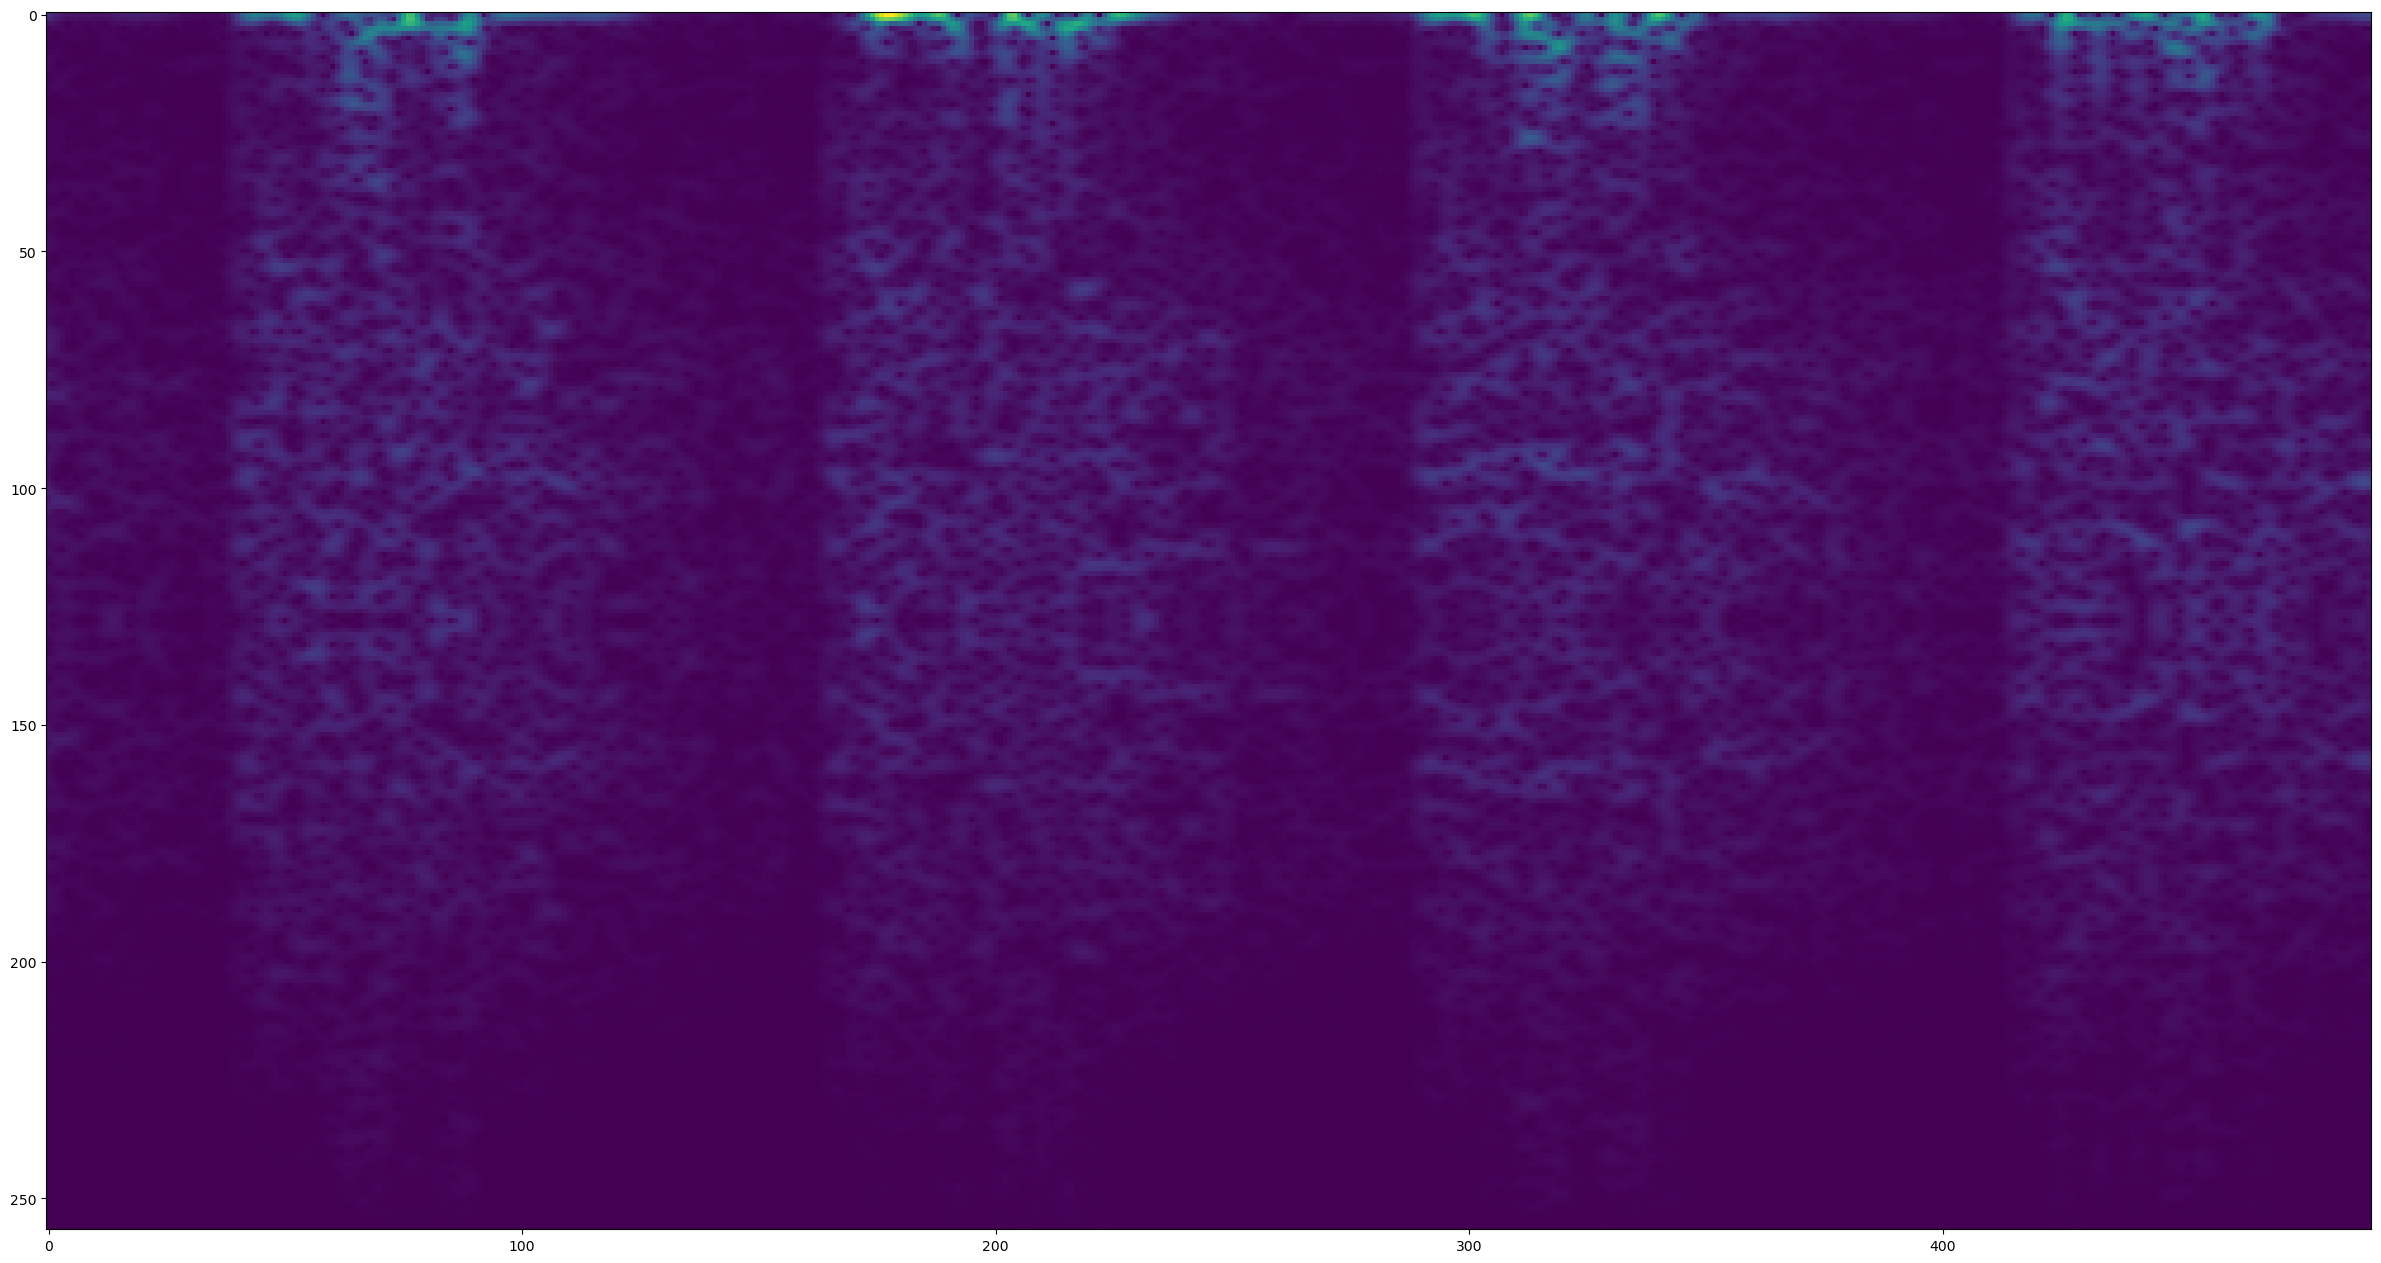

In [19]:
plt.figure(figsize=(30,20))
mel_spectrogram = tfio.audio.melscale(
    spectrogram, rate=16000, mels=128, fmin=0, fmax=8000)
dbscale_mel_spectrogram = tfio.audio.dbscale(
    mel_spectrogram, top_db=80)
# plt.imshow(tf.math.log(mel_spectrogram).numpy()[0])
# plt.imshow(dbscale_mel_spectrogram.numpy()[0])
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# 6. Create Training and Testing Partitions

## 6.1 Create a Tensorflow Data Pipeline

In [20]:
print(len(data))
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

1918


## 6.2 Split into Training and Testing Partitions

In [21]:
len(data)*.8

96.0

In [22]:
train = data.take(int(len(data)*.8))
test = data.skip(int(len(data)*.8)).take(int(len(data)-len(data)*.8))

## 6.3 Test One Batch

In [23]:
samples, labels = train.as_numpy_iterator().next()

In [24]:
labels

array([0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.],
      dtype=float32)

In [25]:
samples.shape

(16, 491, 257, 1)

# 7. Build Deep Learning Model

## 7.1 Load Tensorflow Dependencies

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras import regularizers

## 7.2 Build Sequential Model, Compile and View Summary

In [27]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [53]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision(), tf.keras.metrics.Accuracy()])

In [54]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 489, 255, 16)      160       
                                                                 
 conv2d_1 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 flatten (Flatten)           (None, 1971376)           0         
                                                                 
 dense (Dense)               (None, 128)               252336256 
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 252,338,865
Trainable params: 252,338,865
Non-trainable params: 0
_________________________________________________________________


## 7.3 Fit Model, View Loss and KPI Plots

In [55]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
96/96 [==============================] - 212s 2s/step - loss: 6.5613 - recall_3: 0.8107 - precision_3: 0.6793 - accuracy: 0.1048 - val_loss: 0.0442 - val_recall_3: 1.0000 - val_precision_3: 0.9302 - val_accuracy: 0.0445
Epoch 2/4
96/96 [==============================] - 184s 2s/step - loss: 0.0102 - recall_3: 0.9920 - precision_3: 0.9841 - accuracy: 0.0586 - val_loss: 3.2955e-04 - val_recall_3: 1.0000 - val_precision_3: 1.0000 - val_accuracy: 0.0445
Epoch 3/4
96/96 [==============================] - 186s 2s/step - loss: 1.7800e-04 - recall_3: 1.0000 - precision_3: 1.0000 - accuracy: 0.0723 - val_loss: 2.2436e-05 - val_recall_3: 1.0000 - val_precision_3: 1.0000 - val_accuracy: 0.0445
Epoch 4/4
96/96 [==============================] - 189s 2s/step - loss: 2.9022e-05 - recall_3: 1.0000 - precision_3: 1.0000 - accuracy: 0.0781 - val_loss: 8.0580e-06 - val_recall_3: 1.0000 - val_precision_3: 1.0000 - val_accuracy: 0.0576


In [ ]:
# Save the model
tf.keras.models.save_model('audio_classification_model.h5')

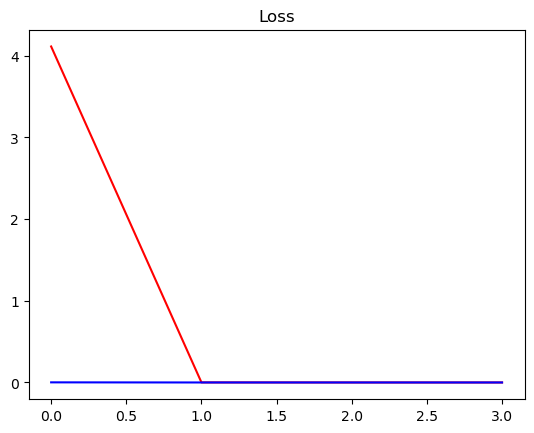

In [36]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

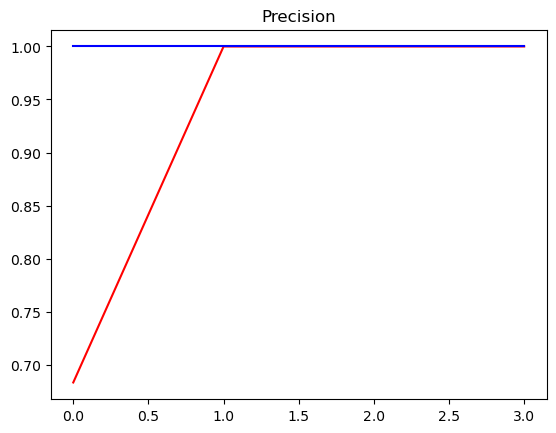

In [37]:
plt.title('Precision')
plt.plot(hist.history['precision'], 'r')
plt.plot(hist.history['val_precision'], 'b')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.title('Accuracy')
plt.plot(hist.history['accuracy'], 'r')
plt.plot(hist.history['val_accuracy'], 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

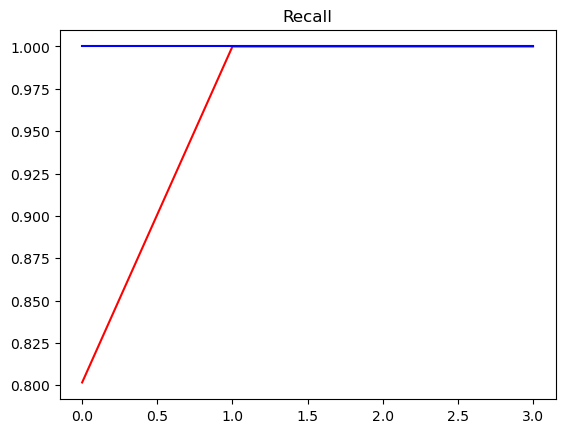

In [103]:
plt.title('Recall')
plt.plot(hist.history['recall'], 'r')
plt.plot(hist.history['val_recall'], 'b')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.show()

In [51]:
# Model version with l2 regularization and dropout

model2 = Sequential()
model2.add(Conv2D(16, (3,3), activation='relu', kernel_regularizer=regularizers.l2(0.001), input_shape=(491, 257,1)))
model2.add(Conv2D(16, (3,3), kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model2.add(BatchNormalization())
model2.add(Flatten())
model2.add(Dense(128, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model2.add(Dropout(0.35))
model2.add(Dense(1, kernel_regularizer=regularizers.l2(0.001), activation='sigmoid'))

model2.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision(), tf.keras.metrics.Accuracy()])

model2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 489, 255, 16)      160       
                                                                 
 conv2d_5 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 batch_normalization_1 (Batc  (None, 487, 253, 16)     64        
 hNormalization)                                                 
                                                                 
 flatten_2 (Flatten)         (None, 1971376)           0         
                                                                 
 dense_4 (Dense)             (None, 128)               252336256 
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                      

In [52]:
# hist2 = model2.fit(train, epochs=8, validation_data=test, batch_size=23)
hist2 = model2.fit(train, epochs=4, validation_data=test)

Epoch 1/4
96/96 [==============================] - 249s 3s/step - loss: 11.7433 - recall_2: 0.9032 - precision_2: 0.8889 - accuracy: 0.9408 - val_loss: 6.5298 - val_recall_2: 1.0000 - val_precision_2: 1.0000 - val_accuracy: 0.1361
Epoch 2/4
96/96 [==============================] - 211s 2s/step - loss: 5.7598 - recall_2: 0.9922 - precision_2: 0.9922 - accuracy: 0.9837 - val_loss: 5.1352 - val_recall_2: 1.0000 - val_precision_2: 1.0000 - val_accuracy: 0.2696
Epoch 3/4
96/96 [==============================] - 216s 2s/step - loss: 5.1484 - recall_2: 0.9919 - precision_2: 0.9880 - accuracy: 0.9909 - val_loss: 4.7496 - val_recall_2: 0.9070 - val_precision_2: 1.0000 - val_accuracy: 0.9450
Epoch 4/4
96/96 [==============================] - 213s 2s/step - loss: 4.0092 - recall_2: 1.0000 - precision_2: 1.0000 - accuracy: 0.9980 - val_loss: 3.3331 - val_recall_2: 1.0000 - val_precision_2: 1.0000 - val_accuracy: 0.9529


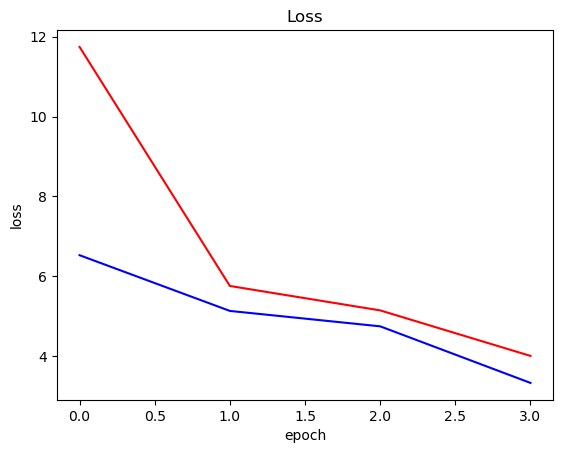

In [56]:
plt.title('Loss')
plt.plot(hist2.history['loss'], 'r')
plt.plot(hist2.history['val_loss'], 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

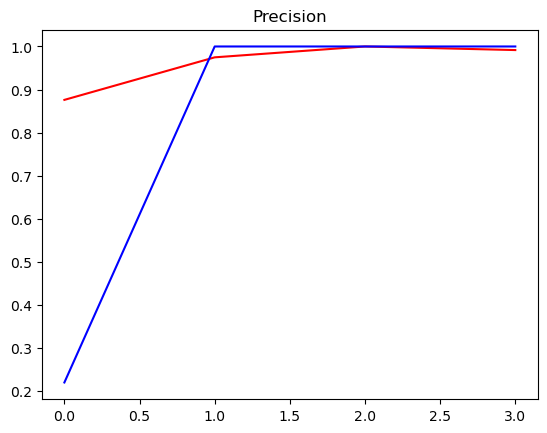

In [49]:
plt.title('Precision')
plt.plot(hist2.history['precision_1'], 'r')
plt.plot(hist2.history['val_precision_1'], 'b')
plt.ylabel('precision')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.title('Accuracy')
plt.plot(hist2.history['accuracy'], 'r')
plt.plot(hist2.history['val_accuracy'], 'b')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

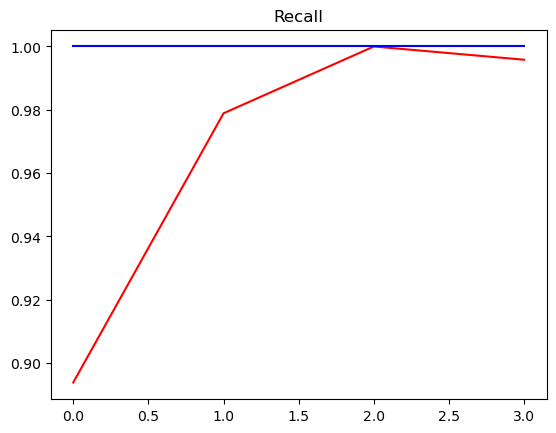

In [50]:
plt.title('Recall')
plt.plot(hist2.history['recall_1'], 'r')
plt.plot(hist2.history['val_recall_1'], 'b')
plt.ylabel('recall')
plt.xlabel('epoch')
plt.show()

# 8. Make a Prediction on a Single Clip

## 8.1 Get One Batch and Make a Prediction

In [32]:
X_test, y_test = test.as_numpy_iterator().next()
print(X_test.shape)
print(y_test.shape)

(16, 491, 257, 1)
(16,)


In [125]:
yhat = model.predict(X_test)
yhat[:3]

1/1 [==============================] - 1s 765ms/step


array([[0.4855838 ],
       [0.43076977],
       [0.44159785]], dtype=float32)

## 8.2 Convert Logits to Classes 

In [126]:
yhat = [1 if prediction > 0.5 else 0 for prediction in yhat]
yhat

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [127]:
print(tf.math.reduce_sum(yhat))
print(tf.math.reduce_sum(y_test))

tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(6.0, shape=(), dtype=float32)


In [128]:
print(yhat)
print(y_test.astype(int))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0 1 1 0 0 0 0 0 1 1 0 0 0 1 1 0]


# 9. Build Forest Parsing Functions

## 9.1 Load up MP3s

In [33]:
#wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
wav_path = os.path.join('./', 'audios', 'test', 'rec6.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec8.wav')

print(wav_path)
wav_path = os.path.join('../','./', 'audios', 'rec', 'rec6.wav')
print(wav_path)

./audios\test\rec6.wav
.././audios\rec\rec6.wav


In [34]:
wav = load_wav_16k_mono(wav_path)
wav.shape

TensorShape([716800])

In [67]:
# print(wav)

import soundfile as sf
import numpy as np
import librosa
import scipy.signal as sps
signal, samplerate = sf.read(wav_path)
signal = np.float32(signal)
samplerate = np.int64(samplerate)
signal = librosa.resample(signal, orig_sr=samplerate, target_sr=160000)
# signal = sps.resample(signal, round(len(signal) * float(16000) / samplerate))
print(signal)



# import librosa
# y, sr = librosa.load(wav_path)
# print(y)

file_contents = tf.io.read_file(wav_path)
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
wav = tf.squeeze(wav, axis=-1)
sample_rate = tf.cast(sample_rate, dtype=tf.int64)
wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
print(wav)


[-0.00110311 -0.00129091 -0.00138292 ...  0.0017152   0.00106631
  0.0005052 ]
tf.Tensor(
[-6.7095005e-09  2.0027615e-08 -5.2226195e-08 ...  2.3132316e-03
  2.4486021e-03  2.4340709e-03], shape=(716800,), dtype=float32)


In [35]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [36]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)

In [37]:
samples, index = audio_slices.as_numpy_iterator().next()

In [38]:
len(audio_slices)

44

In [39]:
samples.shape

(1, 16000)

In [48]:
print(tf.slice(wav,
               begin=[15997],
               size=[1]))
print(samples[0])
print(wav)

import numpy as np
t1 = wav.numpy()

print(np.array_equal(t1[:16000], samples[0]))

print(t1[:16000])
print(samples[0])

print(index)

tf.Tensor([-0.00073242], shape=(1,), dtype=float32)
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
tf.Tensor(
[-0.00115967 -0.00115967 -0.00164795 ...  0.00463867  0.00695801
  0.00695801], shape=(716800,), dtype=float32)
True
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
[-0.00115967 -0.00115967 -0.00164795 ... -0.00073242 -0.00146484
 -0.00146484]
[-0.00115967]


## 9.2 Build Function to Convert Clips into Windowed Spectrograms

In [40]:
def preprocess_2(sample, index):
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

## 9.3 Convert Longer Clips into Windows and Make Predictions

In [41]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
audio_slices = audio_slices.map(preprocess_2)
audio_slices = audio_slices.batch(64)

In [42]:
len(audio_slices)

1

In [139]:
yhat = model.predict(audio_slices)
SCHWELLENWERT = 0.52
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
print(yhat)

1/1 [==============================] - 1s 1s/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Test for audio cutting

In [43]:
# Audio cutting/preparation
from pydub import AudioSegment
import os
import shutil
import numpy as np
import math

# Removes silence at the beginning of wav file
def remove_silence_start(wav_path, output_file, silence_threshold=-46):
    audio = AudioSegment.from_wav(wav_path)
    print("Cutting silence at the beginning of the audio file...")

    # Find index of first not silent sample
    start_index = next((i for i, x in enumerate(audio) if x.dBFS > silence_threshold), None)

    # Safety buffer for not cutting to much of the last valve sound
    safety_margin = 50

    if (start_index is not None) and (start_index > safety_margin):
        # Cut silence at the beginning of the audio
        print(f"Old audio length: {len(audio)} ms")
        audio = audio[start_index - safety_margin:]
        print(f"New audio length: {len(audio)} ms\n")
    else:
        print("No cutting required\n")

    # Save edited file
    audio.export(output_file, format="wav")

# Removes silence at the end of wav file
def remove_silence_end(wav_path, output_file, silence_threshold=-46):
    audio = AudioSegment.from_wav(wav_path)
    print("Cutting silence at the end of the audio file...")

    # Find index of last not silent sample
    end_index = next((len(audio) - 1 - i for i, x in enumerate(reversed(audio)) if x.dBFS > silence_threshold), None)

    # Safety buffer for not cutting to much of the last valve sound
    safety_buffer = 50

    if (end_index is not None) and ((end_index + safety_buffer) < (len(audio) - 1)):
        # Cut silence at the end of the audio
        print(f"Old audio length: {len(audio)} ms")
        audio = audio[:-(len(audio) - (end_index + safety_buffer) - 1)]
        print(f"New audio length: {len(audio)} ms\n")
    else:
        print("No cutting required\n")

    # Save edited file
    audio.export(output_file, format="wav")

# Determine the k-th percentile based on the proportion of valve noise in the audio file
def get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=0.9):
    audio = AudioSegment.from_wav(wav_path)

    # Takes a sample out of the middle of the audio file for the percentile determination -> beginning/end of audio file could contain silence
    # samples = []
    # for i, x in enumerate(audio[len(audio)/2 - 4*(cycle_duration):len(audio)/2]):
    #     samples.append(x.dBFS)

    samples = []
    for i, x in enumerate(audio[len(audio)*0.25 - 4*(cycle_duration):len(audio)*0.25]):
        samples.append(x.dBFS)

    for i, x in enumerate(audio[len(audio)*0.75 - 4*(cycle_duration):len(audio)*0.75]):
        samples.append(x.dBFS)

    # Determines percentile
    noise_percentage = 100 - (100 * (valve_time / cycle_duration))
    percentile_dbfs = np.percentile(samples, noise_percentage)
    percentile_dbfs = math.trunc(percentile_dbfs)
    print(f"{noise_percentage}% of the audio file is quieter than {percentile_dbfs} dBFS")

    # Applying correction factor
    percentile_dbfs *= correction_factor
    print(f"The dBFS with a correction factor of {correction_factor} is {percentile_dbfs}\n")

    return percentile_dbfs

# Cut WAV file in equally long chunks
def split_wav(wav_path, output_directory, valve_time, cycle_duration):
    audio = AudioSegment.from_wav(wav_path)
    print("Splitting wav file into single valve sounds...")

    # Make sure that the output directory exists
    # Or delete old directory from previous script execution
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    else:
        shutil.rmtree(output_directory)
        os.makedirs(output_directory)

    quarter_valve_pause = (cycle_duration - valve_time) / 4
    total_duration = len(audio)
    chunk_number = 1
    current_position = 0

    while current_position < total_duration:
        end_position = current_position + cycle_duration
        if end_position > total_duration:
            end_position = total_duration

        if (current_position - quarter_valve_pause) < 0:
            chunk = audio[current_position:end_position]
        else:
            chunk = audio[current_position - quarter_valve_pause:end_position + quarter_valve_pause]
        current_position = end_position

        chunk_length = len(chunk)
        # Fill last audio chunk with zeroes, if it's too short
        if chunk_length < cycle_duration:
            if chunk_length <= valve_time:
                break
            else:
                chunk += AudioSegment.silent(duration=(cycle_duration - len(chunk)), frame_rate=audio.frame_rate)

        output_file = os.path.join(output_directory, f"{os.path.splitext(os.path.basename(wav_path))[0]}_chunk_{chunk_number}.wav")
        chunk.export(output_file, format="wav")
        chunk_number += 1
    
    print(f"{chunk_number - 1} valve sounds detected\n")

In [44]:
# Audio processing
import tensorflow as tf
import tensorflow_io as tfio

# Build function to convert clips into windowed spectrograms 
# Usage: without load_16k_mono_wav
def preprocess_dir_data_with_padding(wav):
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = 16000
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)

    sample = wav

    sample = wav
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

# Load audio chunks from directory and apply preprocessing
def preprocess_chunks(wav_chunks_dir):
    audio_chunks = tf.keras.utils.audio_dataset_from_directory(
                                wav_chunks_dir,
                                labels=None,
                                label_mode=None,
                                batch_size=1,
                                sampling_rate=None,
                                output_sequence_length=16000,
                                shuffle=False)
    audio_chunks = audio_chunks.map(preprocess_dir_data_with_padding)
    audio_chunks = audio_chunks.batch(128)
    return audio_chunks

In [45]:
# Audio cutting/preparation

# wav_path = os.path.join('../','./', 'audios', 'rec', 'rec5.wav')
wav_path = os.path.join('../','./', 'audios', 'rec', 'val21.wav')
"""
Don't forget to change the machine parameters
"""
valve_time = 20
cycle_duration = 200
"""
Don't forget to change the machine parameters
"""

# Determine the k-th percentile based on the proportion of valve noise in the audio file
percentile_dbfs = get_percentile_dbfs(wav_path, valve_time, cycle_duration, correction_factor=0.86)

# Cutting silence at the beginning of the audio file
output_file = os.path.join(f"{os.path.splitext(wav_path)[0]}_removed_silence_beginning.wav")
remove_silence_start(wav_path, output_file, silence_threshold=percentile_dbfs)

# Cutting silence at the end of the audio file
wav_path = output_file
output_file = os.path.join(f"{os.path.splitext(wav_path)[0]}_and_end.wav")
remove_silence_end(wav_path, output_file, silence_threshold=percentile_dbfs)

# Cutting WAV file in equally long chunks
wav_path = output_file
output_directory = os.path.join('../','./', 'audios', 'rec', 'valve_test_chunks')
split_wav(wav_path, output_directory, valve_time, cycle_duration)

90.0% of the audio file is quieter than -25 dBFS
The dBFS with a correction factor of 0.86 is -21.5

Cutting silence at the beginning of the audio file...
Old audio length: 59904 ms
New audio length: 54904 ms

Cutting silence at the end of the audio file...
Old audio length: 54904 ms
New audio length: 43537 ms

Splitting wav file into single valve sounds...
218 valve sounds detected



In [46]:
# Audio processing

wav_chunks_dir = output_directory
audio_chunks = preprocess_chunks(wav_chunks_dir)

Found 218 files belonging to 1 classes.


In [178]:
# Prediction

yhat = model2.predict(audio_chunks)
SCHWELLENWERT = 0.9
print(yhat)
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
print(yhat)

2/2 [==============================] - 4s 1s/step
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [

In [172]:
# test = [0, 1, 0, 1, 0, 1, 0, 0, 1]

if tf.reduce_sum(yhat).numpy() == 0:
    print("No malfunctions found")
else:
    indices = [index for index, value in enumerate(yhat) if value == 0]
    valve_number = [x + 1 for x in indices]
    print(f"The valve(s) with the following numbers are malfunctioning: {valve_number}")

The valve(s) with the following numbers are malfunctioning: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 108, 109, 110, 111, 113, 115, 124, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 143, 144, 145, 146, 147, 149, 150, 151, 152, 153, 154, 159, 161, 163, 164, 165, 166, 167, 170, 175, 176, 177, 178, 179, 181, 182, 183, 185, 186, 189, 190, 191, 192, 193, 200, 201, 202, 203, 204, 205, 206, 208, 212]


In [120]:
print(len(yhat))

168


## Export Model with preprocessing

In [51]:
class ExportModel(tf.Module):
  def __init__(self, model):
    self.model = model

    # Accept either a string-filename 
    self.__call__.get_concrete_function(
        x=tf.TensorSpec(shape=(), dtype=tf.string))


  @tf.function
  def __call__(self, x):
    
    # Load and adjust audio file
    wav = load_wav_16k_mono(x)

    # Convert longer clips into windows, do preprocessing and create spectrograms
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_2)
    audio_slices = audio_slices.batch(64)

    # Make predictions
    yhat = self.model(audio_slices, training=False)

    return yhat

# Create model with preprocessing that takes path to audio as input
export = ExportModel(model)
# Check model
export(tf.constant(str(wav_path)))

TypeError: in user code:

    File "C:\Users\Kaisky\AppData\Local\Temp\ipykernel_9712\1314803117.py", line 17, in __call__  *
        audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
    File "e:\anaconda3\envs\fourth_industrial_revolution\lib\site-packages\keras\utils\timeseries_dataset.py", line 187, in timeseries_dataset_from_array  **
        if sampling_rate >= len(data):

    TypeError: len is not well defined for a symbolic Tensor (Squeeze:0). Please call `x.shape` rather than `len(x)` for shape information.


In [ ]:
# Save model
tf.saved_model.save(export, "model_with_preprocessing.h5")
# Load saved model
imported = tf.saved_model.load("model_with_preprocessing.h5")
# Check model again
imported(wav_path)

## 9.4 Group Consecutive Detections

In [104]:
from itertools import groupby

In [105]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [106]:
calls

3

# 10. Make Predictions

## 10.1 Loop over all recordings and make predictions

In [107]:
results = {}
for file in os.listdir(os.path.join('data', 'Forest Recordings')):
    FILEPATH = os.path.join('data','Forest Recordings', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)
    
    yhat = model.predict(audio_slices)
    
    results[file] = yhat

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'data\\Forest Recordings'

In [ ]:
results

## 10.2 Convert Predictions into Classes

In [ ]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

## 10.3 Group Consecutive Detections

In [ ]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

# 11. Export Results

In [ ]:
import csv

In [ ]:
with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter=',')
    writer.writerow(['recording', 'capuchin_calls'])
    for key, value in postprocessed.items():
        writer.writerow([key, value])